In [19]:
import numpy as np
import torch
import torch.nn as nn
import sys

In [20]:
# helpers
from collections import defaultdict, Counter
import random
import torch
import torch.nn as nn

def build_local_relation_stats(edge_index, edge_type):
    out_rel_counts = defaultdict(Counter)
    in_rel_counts = defaultdict(Counter)
    pair_rel_counts = defaultdict(Counter)

    src = edge_index[0].tolist()
    dst = edge_index[1].tolist()
    rel = edge_type.tolist()

    for s, r, d in zip(src, rel, dst):
        out_rel_counts[s][r] += 1
        in_rel_counts[d][r] += 1
        pair_rel_counts[(s, d)][r] += 1

    return out_rel_counts, in_rel_counts, pair_rel_counts


def weighted_choice_from_counter(counter, fallback_rels):
    if counter and sum(counter.values()) > 0:
        rels, weights = zip(*counter.items())
        return random.choices(list(rels), weights=list(weights), k=1)[0]
    return random.choice(fallback_rels)

In [21]:
# synthetic data
import sys
sys.path.append('../data_exploration')

from synthetic_dataset_class import SyntheticTemporalGraphDataset

dataset = SyntheticTemporalGraphDataset.from_json(
    "../data_exploration/synthetic_data/2ent_2rel.json"
)

# ---- Dataset-level info ----
print("num timesteps:", len(dataset))
print("x_global shape:", dataset.x_global.shape)   # [num_nodes, embed_dim]
print("relations:", dataset.id_to_rel)

# ---- Single snapshot ----
snap = dataset[10]

print("\n--- Snapshot 10 ---")
print("edge_index shape:", snap.edge_index.shape)        # [2, E]
print("edge_type shape:", snap.edge_type.shape)          # [E]
print("edge_relative_time shape:", snap.edge_relative_time.shape)  # [E]

# ---- Quick consistency check ----
E = snap.edge_index.shape[1]
assert snap.edge_type.shape[0] == E
assert snap.edge_relative_time.shape[0] == E

# ---- Peek at a few edges ----
print("\nFirst 5 edges:")
for i in range(min(5, E)):
    src = snap.edge_index[0, i].item()
    dst = snap.edge_index[1, i].item()
    rel = snap.edge_type[i].item()
    rel_time = snap.edge_relative_time[i].item()

    print(
        f"{dataset.id_to_entity.get(src, src)} -> "
        f"{dataset.id_to_entity.get(dst, dst)} | "
        f"{dataset.id_to_rel.get(rel, rel)} | "
        f"rel_time={rel_time:.2f}"
    )

num timesteps: 200
x_global shape: torch.Size([28, 8])
relations: {0: 'contact', 1: 'bonded'}

--- Snapshot 10 ---
edge_index shape: torch.Size([2, 38])
edge_type shape: torch.Size([38])
edge_relative_time shape: torch.Size([38])

First 5 edges:
A0 -> B5 | contact | rel_time=1.00
A2 -> B4 | bonded | rel_time=2.00
A2 -> B6 | bonded | rel_time=4.00
A2 -> B10 | contact | rel_time=2.00
A2 -> B11 | bonded | rel_time=1.00


In [22]:
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import softmax


class MultiHeadTemporalGAT(MessagePassing):
    def __init__(self, node_dim, edge_emb_dim, num_edge_types, heads=4, dropout=0.1):
        super().__init__(aggr="add")

        # make sure sizing is right
        assert node_dim % heads == 0, "node_dim must be divisible by heads"

        # attributes
        # NOTE: named out_dim to avoid stomping MessagePassing.node_dim
        self.out_dim = node_dim
        self.heads = heads
        self.head_dim = node_dim // heads
        self.dropout = dropout

        # edge embeddings
        self.edge_embedding = nn.Embedding(num_edge_types, edge_emb_dim)

        # projections
        self.W_h = nn.Linear(node_dim, node_dim, bias=False) # for node embeddings in message
        self.W_r = nn.Linear(edge_emb_dim, node_dim, bias=False) # for edge embeddings in message
        self.W_n = nn.Linear(node_dim, node_dim, bias=False) # for node embeddings in attention

        # attention MLP operates per head
        # shared accross all heads (not as good as full multihead, but much cheaper)
        # expects concat of both node embeddings and the edge embedding
        # outputs a scalar, the attention score
        self.att_mlp = nn.Sequential(
            nn.Linear(2 * self.head_dim + edge_emb_dim, self.head_dim),
            nn.LeakyReLU(),
            nn.Linear(self.head_dim, 1)
        )

        # output and normalization
        self.out_proj = nn.Linear(node_dim, node_dim)
        self.norm = nn.LayerNorm(node_dim)

    def forward(self, x, edge_index, edge_type):
        # dims
        # x is (num_nodes, node_dim)
        # edge_index is (2, num_edges)
        # edge_type is (num_edges)

        # get edge embeddings (num_edges, edge_emb_dim)
        edge_attr = self.edge_embedding(edge_type)

        # propagates messages
        out = self.propagate(edge_index, x=x, edge_attr=edge_attr)

        # serves to mix info from different heads
        out = self.out_proj(out)

        # residual and norm
        return self.norm(x + out)

    # message is called in propagate
    def message(self, x_i, x_j, edge_attr, index):
        # apply transfomation to node embeddings
        z_i = self.W_n(x_i) # (num_edges, node_dim)
        z_j = self.W_n(x_j)

        # apply message transfomation to node embedding
        m_j = self.W_h(x_j) # (num_edges, node_dim)

        # apply message transformation to edge embedding and project to node space
        e_j = self.W_r(edge_attr) # (num_edges, node_dim)

        # reshape (num_edges, heads, head_dim) for multihead attention
        z_i = z_i.view(-1, self.heads, self.head_dim)
        z_j = z_j.view(-1, self.heads, self.head_dim)
        m_j = m_j.view(-1, self.heads, self.head_dim)
        e_j = e_j.view(-1, self.heads, self.head_dim)

        # expand edge_attr to heads (num_edges, num_heads, edge_emb_dim)
        # for attention
        edge_attr = edge_attr.unsqueeze(1).repeat(1, self.heads, 1)

        # attention per head
        att_input = torch.cat([z_i, z_j, edge_attr], dim=-1) # (num_edges, num_heads, (2 * head_dim + edge_emb_dim))
        e_ij = self.att_mlp(att_input).squeeze(-1)   # (num_edges, heads)

        # apply softmax to attention scores to get attention weights
        alpha = softmax(e_ij, index)                 # normalize per node
        alpha = F.dropout(alpha, p=self.dropout, training=self.training)

        # calculate messages
        msg = m_j + e_j     # (num_edges, num_heads, head_dim)

        # weight messages and return
        return alpha.unsqueeze(-1) * msg   # (num_edges, heads, head_dim)

    def aggregate(self, inputs, index, ptr=None, dim_size=None):
        # inputs: (num_edges, heads, head_dim) -> flatten heads before scatter
        # use self.out_dim instead of -1 to handle the zero-edge case safely
        inputs_flat = inputs.view(inputs.size(0), self.out_dim)   # (num_edges, out_dim)
        return super().aggregate(inputs_flat, index, ptr, dim_size)  # (num_nodes, out_dim)


In [23]:
class NodeLSTM(nn.Module):
    """
    Per-node temporal memory module.

    Input:
        x_t: current node representations at time t
             shape [num_nodes, input_dim]

        state: optional tuple (h_prev, c_prev)
             h_prev: [num_nodes, hidden_dim]
             c_prev: [num_nodes, hidden_dim]

    Output:
        h_t: updated node hidden states
             shape [num_nodes, hidden_dim]

        (h_t, c_t): updated recurrent state
    """

    def __init__(self, input_dim, hidden_dim):
        super().__init__()

        self.input_dim = input_dim
        self.hidden_dim = hidden_dim

        self.cell = nn.LSTMCell(input_dim, hidden_dim)

    def init_state(self, num_nodes, device):
        h0 = torch.zeros(num_nodes, self.hidden_dim, device=device)
        c0 = torch.zeros(num_nodes, self.hidden_dim, device=device)
        return h0, c0

    def forward(self, x_t, state=None):
        """
        x_t: [num_nodes, input_dim]
        state: (h_prev, c_prev) or None
        """
        num_nodes = x_t.size(0)
        device = x_t.device

        if state is None:
            h_prev, c_prev = self.init_state(num_nodes, device)
        else:
            h_prev, c_prev = state

        # LSTMCell treats num_nodes like the batch dimension,
        # so each node gets its own temporal update.
        h_t, c_t = self.cell(x_t, (h_prev, c_prev))

        return h_t, (h_t, c_t)

In [24]:
from collections import defaultdict
import itertools
import random


class TripleProposalStrategy:
    def propose(self, edge_index, edge_type, graph_node_states, lstm_node_states,
                target_count=None, metadata=None):
        raise NotImplementedError

# add all current edges
class CurrentEdgeSetStrategy(TripleProposalStrategy):
    """Passes every edge in the current graph as a candidate."""

    def propose(self, edge_index, edge_type, graph_node_states, lstm_node_states,
                target_count=None, metadata=None):
        src = edge_index[0].tolist()
        dst = edge_index[1].tolist()
        rel = edge_type.tolist()
        return list(zip(src, rel, dst))

# all possible edges
# only use for testing on small graphs. Blows up fast
class AllTripletStrategy(TripleProposalStrategy):
    def __init__(self, allowed_relations):
        self.allowed_relations = allowed_relations

    def propose(self, edge_index, edge_type, graph_node_states, lstm_node_states,
                target_count=None, metadata=None):
        active = edge_index.unique().tolist()
        proposals = [
            (u, r, v)
            for u, v in itertools.permutations(active, 2)
            for r in self.allowed_relations
        ]
        return proposals


# anything within len-2 path
class TwoHopRelationAwareStrategy(TripleProposalStrategy):
    def __init__(self, allowed_relations, max_per_node=10):
        self.allowed_relations = allowed_relations
        self.max_per_node = max_per_node

    def propose(self, edge_index, edge_type, graph_node_states, lstm_node_states,
                target_count=None, metadata=None):
        active_nodes = edge_index.unique().tolist()
        if not active_nodes:
            return []

        out_neighbors = defaultdict(list)
        for s, d in zip(edge_index[0].tolist(), edge_index[1].tolist()):
            out_neighbors[s].append(d)

        out_rel_counts, in_rel_counts, pair_rel_counts = build_local_relation_stats(edge_index, edge_type)

        rels = list(self.allowed_relations)
        if not rels:
            return []

        proposals = set()

        def choose_relation(u, v):
            # Prefer pair-specific relation history, then source out-relations, then destination in-relations.
            if pair_rel_counts[(u, v)]:
                return weighted_choice_from_counter(pair_rel_counts[(u, v)], rels)
            merged = out_rel_counts[u] + in_rel_counts[v]
            return weighted_choice_from_counter(merged, rels)

        if target_count is not None:
            max_iters = target_count * 20
            iters = 0
            while len(proposals) < target_count and iters < max_iters:
                u = random.choice(active_nodes)
                mids = out_neighbors[u]
                if not mids:
                    iters += 1
                    continue
                mid = random.choice(mids)
                vs = out_neighbors[mid]
                if not vs:
                    iters += 1
                    continue
                v = random.choice(vs)
                if v == u:
                    iters += 1
                    continue

                r = choose_relation(u, v)
                proposals.add((u, r, v))
                iters += 1
        else:
            random.shuffle(active_nodes)
            for u in active_nodes:
                mids = list(out_neighbors[u])
                random.shuffle(mids)
                count = 0
                for mid in mids:
                    vs = [v for v in out_neighbors[mid] if v != u]
                    if not vs:
                        continue
                    v = random.choice(vs)
                    r = choose_relation(u, v)
                    proposals.add((u, r, v))
                    count += 1
                    if count >= self.max_per_node:
                        break

        return list(proposals)

# similarity between nodes (cosine)
class SimilarHybridStateStrategy(TripleProposalStrategy):
    def __init__(self, allowed_relations, topk=10, sample_pool_factor=3):
        self.allowed_relations = allowed_relations
        self.topk = topk
        self.sample_pool_factor = sample_pool_factor

    def propose(self, edge_index, edge_type, graph_node_states, lstm_node_states,
                target_count=None, metadata=None):
        active = edge_index.unique()
        if active.numel() == 0:
            return []

        rels = list(self.allowed_relations)
        if not rels:
            return []

        x = torch.cat([graph_node_states[active], lstm_node_states[active]], dim=-1)
        x_norm = x / (x.norm(dim=-1, keepdim=True) + 1e-8)
        sim = x_norm @ x_norm.T

        active_list = active.tolist()
        out_rel_counts, in_rel_counts, pair_rel_counts = build_local_relation_stats(edge_index, edge_type)

        def choose_relation(u, v):
            if pair_rel_counts[(u, v)]:
                return weighted_choice_from_counter(pair_rel_counts[(u, v)], rels)
            merged = out_rel_counts[u] + in_rel_counts[v]
            return weighted_choice_from_counter(merged, rels)

        pool_k = min(self.topk * self.sample_pool_factor + 1, sim.size(1))
        topk_neighbors = {}
        for i, u in enumerate(active_list):
            _, indices = torch.topk(sim[i], k=pool_k)
            neighbors = [active[j].item() for j in indices.tolist() if active[j].item() != u]
            topk_neighbors[u] = neighbors[:self.topk]

        proposals = set()

        max_needed = target_count if target_count is not None else len(active_list) * self.topk
        max_iters = max_needed * 20

        iters = 0
        while len(proposals) < max_needed and iters < max_iters:
            u = random.choice(active_list)
            nbrs = topk_neighbors[u]
            if not nbrs:
                iters += 1
                continue
            v = random.choice(nbrs)
            r = choose_relation(u, v)
            proposals.add((u, r, v))
            iters += 1

        return list(proposals)
    
    
class HistoricalEdgeStrategy(TripleProposalStrategy):
    def __init__(self, allowed_relations, max_history=5):
        self.allowed_relations = allowed_relations
        self.max_history = max_history

    def propose(self, edge_index, edge_type, graph_node_states, lstm_node_states,
                target_count=None, metadata=None):
        # metadata should contain:
        #   metadata["history_edge_sets"] = deque/list of prior edge sets
        if metadata is None or "history_edge_sets" not in metadata:
            return []

        current_set = set(zip(
            edge_index[0].tolist(),
            edge_type.tolist(),
            edge_index[1].tolist()
        ))

        history_edge_sets = metadata["history_edge_sets"]
        pool = set()

        for edge_set in history_edge_sets:
            for triple in edge_set:
                if triple not in current_set:
                    pool.add(triple)

        pool = list(pool)
        if not pool:
            return []

        if target_count is not None and len(pool) > target_count:
            pool = random.sample(pool, target_count)

        return pool


class RandomCorruptionStrategy(TripleProposalStrategy):
    def __init__(self, allowed_relations):
        self.allowed_relations = allowed_relations

    def propose(self, edge_index, edge_type, graph_node_states, lstm_node_states,
                target_count=None, metadata=None):
        active = edge_index.unique().tolist()
        if len(active) < 2:
            return []

        current_set = set(zip(
            edge_index[0].tolist(),
            edge_type.tolist(),
            edge_index[1].tolist()
        ))

        proposals = set()
        max_needed = target_count if target_count is not None else len(current_set)
        max_iters = max_needed * 20

        iters = 0
        while len(proposals) < max_needed and iters < max_iters:
            s = random.choice(active)
            d = random.choice(active)
            if s == d:
                iters += 1
                continue
            r = random.choice(self.allowed_relations)
            t = (s, r, d)
            if t not in current_set:
                proposals.add(t)
            iters += 1

        return list(proposals)
    
class BudgetedTripleProposer(nn.Module):
    def __init__(self, current_strategy, strategy_budgets):
        super().__init__()
        # strategy_budgets: list of (name, strategy, budget)
        self.current_strategy = current_strategy
        self.strategy_budgets = strategy_budgets

    def propose_additions(self, edge_index, edge_type, graph_node_states, lstm_node_states,
                          target_count=None, metadata=None):
        current_set = set(self.current_strategy.propose(
            edge_index=edge_index,
            edge_type=edge_type,
            graph_node_states=graph_node_states,
            lstm_node_states=lstm_node_states,
            metadata=metadata,
        ))

        other_set = set()

        # optionally scale budgets if target_count is provided
        if target_count is not None:
            total_budget = sum(b for _, _, b in self.strategy_budgets)
            if total_budget > 0:
                scaled_strategy_budgets = []
                for name, strategy, budget in self.strategy_budgets:
                    scaled_budget = max(1, int(round(target_count * budget / total_budget)))
                    scaled_strategy_budgets.append((name, strategy, scaled_budget))
            else:
                scaled_strategy_budgets = self.strategy_budgets
        else:
            scaled_strategy_budgets = self.strategy_budgets

        for _, strategy, budget in scaled_strategy_budgets:
            props = strategy.propose(
                edge_index=edge_index,
                edge_type=edge_type,
                graph_node_states=graph_node_states,
                lstm_node_states=lstm_node_states,
                target_count=budget,
                metadata=metadata,
            )
            for p in props:
                if p not in current_set:
                    other_set.add(p)

        if not other_set:
            return torch.empty((0, 3), dtype=torch.long, device=graph_node_states.device)

        return torch.tensor(list(other_set), dtype=torch.long, device=graph_node_states.device)

# collects and calls strategies
# returns sample size pos triplets from the current edge strategy (always first)
# returns sample size neg triplets from sampling strategies
# ensures balance of positive and negative datapoints
class TripleProposer(nn.Module):
    def __init__(self, strategies, sample_size=None):
        """
        strategies  : list of TripleProposalStrategy; first must be CurrentEdgeSetStrategy
        sample_size : if set, randomly sample exactly this many from current edges
                      AND this many from non-current proposals, giving a balanced
                      50/50 candidate set of size 2 * sample_size
        """
        super().__init__()
        self.strategies = strategies
        self.sample_size = sample_size

    def forward(self, edge_index, edge_type, graph_node_states, lstm_node_states, metadata=None):
        current_set = set(self.strategies[0].propose(
            edge_index=edge_index, edge_type=edge_type,
            graph_node_states=graph_node_states, lstm_node_states=lstm_node_states,
        ))

        other_set = set()
        for strategy in self.strategies[1:]:
            for p in strategy.propose(
                edge_index=edge_index, edge_type=edge_type,
                graph_node_states=graph_node_states, lstm_node_states=lstm_node_states,
                target_count=self.sample_size,
            ):
                if p not in current_set:
                    other_set.add(p)

        current_list = list(current_set)
        other_list = list(other_set)

        # use getattr for backward compatibility with models pickled before sample_size was added
        sample_size = getattr(self, 'sample_size', None)

        if sample_size is not None:
            # sample equally from each side for a balanced candidate set
            if len(current_list) > sample_size:
                current_list = random.sample(current_list, sample_size)
            if len(other_list) > sample_size:
                other_list = random.sample(other_list, sample_size)

        all_proposals = current_list + other_list
        num_current = len(current_list)

        if len(all_proposals) == 0:
            return torch.empty((0, 3), dtype=torch.long, device=graph_node_states.device), 0

        return (
            torch.tensor(all_proposals, dtype=torch.long, device=graph_node_states.device),
            num_current,
        )

    def propose_additions(self, edge_index, edge_type, graph_node_states, lstm_node_states,
                          target_count=None, metadata=None):
        """
        Returns non-current proposals for the addition head.
        target_count: how many proposals each strategy should aim to generate.
        No proposer-level cap — build_add_candidates handles balancing via SAMPLE_SIZE.
        """
        current_set = set(self.strategies[0].propose(
            edge_index=edge_index, edge_type=edge_type,
            graph_node_states=graph_node_states, lstm_node_states=lstm_node_states,
        ))

        other_set = set()
        for strategy in self.strategies[1:]:
            for p in strategy.propose(
                edge_index=edge_index, edge_type=edge_type,
                graph_node_states=graph_node_states, lstm_node_states=lstm_node_states,
                target_count=target_count,
            ):
                if p not in current_set:
                    other_set.add(p)

        if not other_set:
            return torch.empty((0, 3), dtype=torch.long, device=graph_node_states.device)

        return torch.tensor(list(other_set), dtype=torch.long, device=graph_node_states.device)

In [25]:
class TripleScorer(nn.Module):
    def __init__(self, graph_dim, lstm_dim, num_relations, hidden_dim, rel_dim, use_rel_time=False):
        super().__init__()

        self.graph_dim    = graph_dim
        self.lstm_dim     = lstm_dim
        self.node_dim     = graph_dim + lstm_dim
        self.rel_dim      = rel_dim if rel_dim is not None else self.node_dim
        self.use_rel_time = use_rel_time

        self.rel_emb = nn.Embedding(num_relations, self.rel_dim)

        # project node states down to rel_dim for DistMult compatibility
        self.node_proj = nn.Linear(self.node_dim, self.rel_dim, bias=False)

        # MLP on top of DistMult score + raw triple features
        # keeps expressivity while adding relation-structured inductive bias
        # if use_rel_time, also concatenates log1p(edge_relative_time) as an extra scalar feature
        mlp_in = self.rel_dim + 1 + (1 if use_rel_time else 0)
        self.mlp = nn.Sequential(
            nn.Linear(mlp_in, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, graph_node_states, lstm_node_states, proposed_triples, edge_rel_time=None):
        if proposed_triples.dtype != torch.long:
            proposed_triples = proposed_triples.long()

        src = proposed_triples[:, 0]
        rel = proposed_triples[:, 1]
        dst = proposed_triples[:, 2]

        src_state = torch.cat([graph_node_states[src], lstm_node_states[src]], dim=-1)
        dst_state = torch.cat([graph_node_states[dst], lstm_node_states[dst]], dim=-1)

        # project to rel_dim so dimensions match for elementwise product
        src_proj = self.node_proj(src_state)   # [N, rel_dim]
        dst_proj = self.node_proj(dst_state)   # [N, rel_dim]
        rel_emb  = self.rel_emb(rel)           # [N, rel_dim]

        # DistMult: relation gates which feature dimensions matter
        distmult_score = (src_proj * rel_emb * dst_proj).sum(dim=-1, keepdim=True)  # [N, 1]

        # combine DistMult score with projected src for a richer signal
        features = torch.cat([src_proj * rel_emb, distmult_score], dim=-1)  # [N, rel_dim + 1]

        # append log1p(edge age) so the deletion head knows how long each edge has existed.
        # log1p compresses the long tail: a 1-step-old vs 100-step-old edge matters
        # more than a 500-step-old vs 600-step-old edge.
        if self.use_rel_time:
            if edge_rel_time is None:
                # default to age 0 if not provided
                age = torch.zeros(proposed_triples.size(0), 1, device=proposed_triples.device)
            else:
                age = torch.log1p(edge_rel_time).unsqueeze(-1)   # [N, 1]
            features = torch.cat([features, age], dim=-1)        # [N, rel_dim + 2]

        logits = self.mlp(features).squeeze(-1)  # [N]

        return logits

In [26]:
def compute_deltas(edge_index_t, edge_type_t, edge_index_next, edge_type_next):
    """
    Compute added and deleted triples between two consecutive timesteps.

    Returns:
        added   : LongTensor [num_added,   3]  triples in t+1 but not t  (src, rel, dst)
        deleted : LongTensor [num_deleted, 3]  triples in t   but not t+1
    """
    device = edge_index_t.device

    current_set = set(zip(
        edge_index_t[0].tolist(), edge_type_t.tolist(), edge_index_t[1].tolist()
    ))
    next_set = set(zip(
        edge_index_next[0].tolist(), edge_type_next.tolist(), edge_index_next[1].tolist()
    ))

    added_list   = sorted(next_set - current_set)
    deleted_list = sorted(current_set - next_set)

    added   = (torch.tensor(added_list,   dtype=torch.long, device=device)
               if added_list   else torch.empty((0, 3), dtype=torch.long, device=device))
    deleted = (torch.tensor(deleted_list, dtype=torch.long, device=device)
               if deleted_list else torch.empty((0, 3), dtype=torch.long, device=device))

    return added, deleted


def delta_bce_loss(candidates, logits, positive_triples):
    """
    Unweighted BCE loss for a single delta head (deletion or addition).

    candidates       : LongTensor [N, 3] — triples fed to the head
    logits           : Tensor [N]        — raw scores from head
    positive_triples : LongTensor [P, 3] — ground-truth positives (true deletions or additions)

    Labels: 1.0 if the candidate is in positive_triples, else 0.0.
    Returns: (loss, labels, positive_mask)
    """
    device = candidates.device

    if positive_triples.size(0) > 0:
        pos_set = set(map(tuple, positive_triples.cpu().tolist()))
        labels = torch.tensor(
            [1.0 if tuple(t) in pos_set else 0.0 for t in candidates.cpu().tolist()],
            dtype=logits.dtype, device=device,
        )
    else:
        labels = torch.zeros(candidates.size(0), dtype=logits.dtype, device=device)

    loss = F.binary_cross_entropy_with_logits(logits, labels, reduction="mean")
    return loss, labels, labels.bool()


In [27]:
import os
import itertools
import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import display as ipy_display
from collections import deque


class Temporal_Delta_GNN(nn.Module):
    """
    Delta-based temporal GNN.

    Instead of predicting the full next graph, it predicts two deltas:
      - deletion head : which current edges will be removed
      - addition head : which candidate edges will be added

    Training candidates per head are balanced (equal positives and negatives):
      Deletion  — positives: true deleted edges
                  negatives: randomly sampled surviving current edges
      Addition  — positives: true added edges
                  negatives: randomly sampled non-added proposals from candidate strategies
    """

    def __init__(
        self,
        in_dim,
        hidden_dim,
        edge_emb_dim,
        num_edge_types,
        num_gnn_layers=2,
        heads=4,
        dropout=0.1,
    ):
        super().__init__()

        self.hidden_dim = hidden_dim
        self.num_edge_types = num_edge_types

        # project pretrained semantic embeddings into hidden_dim
        self.init_embedding = nn.Linear(in_dim, hidden_dim)

        # stack of GNN layers
        self.gnn_layers = nn.ModuleList([
            MultiHeadTemporalGAT(hidden_dim, edge_emb_dim, num_edge_types, heads=heads, dropout=dropout)
            for _ in range(num_gnn_layers)
        ])

        # per-node temporal memory
        self.node_lstm = NodeLSTM(hidden_dim, hidden_dim)

        all_rels = list(range(num_edge_types))

        self.proposer = BudgetedTripleProposer(
            current_strategy=CurrentEdgeSetStrategy(),
            strategy_budgets=[
                ("two_hop",    TwoHopRelationAwareStrategy(all_rels, max_per_node=10), 200),
                ("similar",    SimilarHybridStateStrategy(all_rels, topk=5, sample_pool_factor=3), 150),
                ("historical", HistoricalEdgeStrategy(all_rels, max_history=5), 100),
                ("random",     RandomCorruptionStrategy(all_rels), 50),
            ],
        )

        # deletion head: scores current edges, predicts which will be removed.
        # use_rel_time=True — the deletion scorer receives each edge's age as an extra
        # feature, giving it a direct signal that older edges are more stable.
        self.deletion_scorer = TripleScorer(
            graph_dim=hidden_dim,
            lstm_dim=hidden_dim,
            num_relations=num_edge_types,
            hidden_dim=hidden_dim,
            rel_dim=edge_emb_dim,
            use_rel_time=True,
        )

        # addition head: scores non-current candidates, predicts which will appear.
        # no rel_time needed — proposed edges don't exist yet so have no age.
        self.addition_scorer = TripleScorer(
            graph_dim=hidden_dim,
            lstm_dim=hidden_dim,
            num_relations=num_edge_types,
            hidden_dim=hidden_dim,
            rel_dim=edge_emb_dim,
        )

    def _encode(self, x_global, edge_index, edge_type, lstm_state=None):
        """Run GNN + LSTM, return (graph_node_states, lstm_h, lstm_state)."""
        # x_global:   [num_nodes, in_dim]
        # edge_index: [2, num_edges]
        # edge_type:  [num_edges]

        # project to hidden dim
        x = self.init_embedding(x_global)       # [num_nodes, hidden_dim]

        # GNN layers
        for gnn in self.gnn_layers:
            x = gnn(x, edge_index, edge_type)

        graph_node_states = x                   # [num_nodes, hidden_dim]

        # update per-node LSTM
        lstm_h, lstm_state = self.node_lstm(graph_node_states, lstm_state)

        return graph_node_states, lstm_h, lstm_state

    def forward(self, x_global, edge_index, edge_type,
                del_candidates, add_candidates, lstm_state=None):
        """
        x_global       : [num_nodes, in_dim]
        edge_index     : [2, num_edges]
        edge_type      : [num_edges]
        del_candidates : LongTensor [D, 3] — subset of current edges to score for deletion
        add_candidates : LongTensor [A, 3] — non-current candidates to score for addition
        lstm_state     : (h, c) or None

        Returns: del_logits [D], add_logits [A], lstm_state
        """
        graph_node_states, lstm_h, lstm_state = self._encode(
            x_global, edge_index, edge_type, lstm_state
        )

        # score deletion candidates (subset of current edges)
        if del_candidates.size(0) > 0:
            del_logits = self.deletion_scorer(graph_node_states, lstm_h, del_candidates)
        else:
            del_logits = torch.empty(0, device=del_candidates.device)

        # score addition candidates (non-current proposals)
        if add_candidates.size(0) > 0:
            add_logits = self.addition_scorer(graph_node_states, lstm_h, add_candidates)
        else:
            add_logits = torch.empty(0, device=add_candidates.device)

        return del_logits, add_logits, lstm_state

    @torch.no_grad()
    def gen(self, x_global, edge_index, edge_type,
            edge_rel_time=None,
            num_steps=5, device='cpu', history_len=5,
            sampling='bernoulli', add_threshold=0.5, del_threshold=0.5):
        """
        Run the delta model forward for num_steps steps.

        Returns a list of dicts, one per step:
            {
                "edge_index" : LongTensor [2, E]   — edges after applying delta
                "edge_type"  : LongTensor [E]
                "added"      : set of (src, rel, dst) tuples added this step
                "removed"    : set of (src, rel, dst) tuples removed this step
                "edge_set"   : set of (src, rel, dst) — full edge set after delta
            }

        Addition candidates are ALL non-current (u, r, v) triples over the active
        node set × all relations — exhaustive scoring, not sampled. Only feasible
        on small subgraphs; use sample_subgraph before calling gen().

        edge_rel_time : FloatTensor [E] — relative time (age) for each edge in the
                        starting snapshot, aligned with edge_index/edge_type. If None,
                        all edges start at age 0. Ages are tracked across gen steps:
                        surviving edges increment by 1 per step, new edges start at 0.
        sampling      : 'bernoulli' — treat each sigmoid score as a Bernoulli probability
                        (stochastic; produces visible dynamics even with untrained models
                        since logits≈0 → p≈0.5 → ~half the candidates flip each step).
                        'threshold' — predict positive when sigmoid(logit) > threshold
                        (deterministic; requires a calibrated model — may predict nothing
                        if model is untrained since sigmoid(0)=0.5 and 0.5>0.5 is False).
        add_threshold / del_threshold: only used when sampling='threshold'.
        history_len   : number of past edge sets kept in rolling history (unused in gen,
                        retained for API consistency with training).
        """
        self.eval()
        x_global   = x_global.to(device)
        edge_index = edge_index.to(device)
        edge_type  = edge_type.to(device)
        lstm_state = None
        all_rels   = list(range(self.num_edge_types))

        prev_edge_set = set(zip(
            edge_index[0].cpu().tolist(),
            edge_type.cpu().tolist(),
            edge_index[1].cpu().tolist(),
        ))

        # build initial rel_time_map from the starting snapshot's edge_relative_time.
        # each entry maps (src, rel, dst) -> float age.
        # if not provided, all edges default to age 0.0.
        if edge_rel_time is not None:
            src_list = edge_index[0].cpu().tolist()
            rel_list = edge_type.cpu().tolist()
            dst_list = edge_index[1].cpu().tolist()
            time_list = edge_rel_time.cpu().tolist()
            rel_time_map = {
                (s, r, d): t
                for s, r, d, t in zip(src_list, rel_list, dst_list, time_list)
            }
        else:
            rel_time_map = {triple: 0.0 for triple in prev_edge_set}

        steps = []

        for step in range(num_steps):
            if not prev_edge_set:
                print(f"step {step + 1}: graph is empty, stopping.")
                break

            graph_node_states, lstm_h, lstm_state = self._encode(
                x_global, edge_index, edge_type, lstm_state
            )

            # --- deletion: score ALL current edges ---
            # sort for determinism; rel_time lookup uses the same order
            del_triples_sorted = sorted(prev_edge_set)
            del_cands     = torch.tensor(del_triples_sorted, dtype=torch.long, device=device)
            del_rel_times = torch.tensor(
                [rel_time_map.get(t, 0.0) for t in del_triples_sorted],
                dtype=torch.float, device=device,
            )
            del_logits = self.deletion_scorer(
                graph_node_states, lstm_h, del_cands, edge_rel_time=del_rel_times
            )

            # --- addition: score ALL non-current triples over active nodes x all relations.
            # exhaustive — only feasible on small subgraphs; use sample_subgraph before
            # calling gen() to keep this tractable.
            active_nodes = edge_index.unique().tolist()
            all_possible = [
                (u, r, v)
                for u, v in itertools.permutations(active_nodes, 2)
                for r in all_rels
                if (u, r, v) not in prev_edge_set
            ]
            if all_possible:
                add_cands  = torch.tensor(all_possible, dtype=torch.long, device=device)
                add_logits = self.addition_scorer(graph_node_states, lstm_h, add_cands)
            else:
                add_cands  = torch.empty((0, 3), dtype=torch.long, device=device)
                add_logits = torch.empty(0, device=device)

            # --- apply sampling strategy ---
            del_probs = torch.sigmoid(del_logits)
            if sampling == 'bernoulli':
                # stochastic: treat each score as a Bernoulli probability.
                # produces visible dynamics even with untrained models (logits≈0 → p≈0.5).
                to_delete_set = set(map(tuple, del_cands[torch.bernoulli(del_probs).bool()].cpu().tolist()))
            else:
                # deterministic threshold: predict positive when p > del_threshold.
                # requires a calibrated model; may predict nothing if model is untrained
                # (sigmoid(0)=0.5, and 0.5 > 0.5 is False).
                to_delete_set = set(map(tuple, del_cands[del_probs > del_threshold].cpu().tolist()))

            if add_cands.size(0) > 0:
                add_probs = torch.sigmoid(add_logits)
                if sampling == 'bernoulli':
                    to_add_set = set(map(tuple, add_cands[torch.bernoulli(add_probs).bool()].cpu().tolist()))
                else:
                    to_add_set = set(map(tuple, add_cands[add_probs > add_threshold].cpu().tolist()))
            else:
                to_add_set = set()

            # apply delta: remove deletions, union in additions
            new_edge_set = (prev_edge_set - to_delete_set) | to_add_set

            if not new_edge_set:
                print(f"step {step + 1}: all edges deleted, stopping.")
                break

            # rebuild edge tensors
            new_triples    = sorted(new_edge_set)
            new_tensor     = torch.tensor(new_triples, dtype=torch.long, device=device)
            new_edge_index = torch.stack([new_tensor[:, 0], new_tensor[:, 2]], dim=0)
            new_edge_type  = new_tensor[:, 1]

            steps.append({
                "edge_index" : new_edge_index.cpu(),
                "edge_type"  : new_edge_type.cpu(),
                "added"      : to_add_set,
                "removed"    : to_delete_set,
                "edge_set"   : new_edge_set,
            })

            print(
                f"step {step + 1}: {new_edge_index.unique().numel()} nodes, "
                f"{new_edge_index.size(1)} edges  "
                f"+{len(to_add_set)} added, -{len(to_delete_set)} removed"
            )

            # update rel_time_map: surviving edges age by 1, new edges start at 0,
            # deleted edges drop out of the map entirely.
            new_rel_time_map = {}
            for triple in new_edge_set:
                if triple in to_add_set:
                    new_rel_time_map[triple] = 0.0                          # newly added — age 0
                else:
                    new_rel_time_map[triple] = rel_time_map.get(triple, 0.0) + 1.0  # survived — age +1
            rel_time_map = new_rel_time_map

            # advance state for the next step
            edge_index    = new_edge_index.to(device)
            edge_type     = new_edge_type.to(device)
            prev_edge_set = new_edge_set

        return steps

In [28]:
def corrupt_relations(triples_list, num_relations, corrupt_prob=0.3):
    """Replace relation with a random one for a subset of negative triples."""
    corrupted = []
    for s, r, d in triples_list:
        if random.random() < corrupt_prob:
            r = random.randint(0, num_relations - 1)
        corrupted.append((s, r, d))
    return corrupted

In [29]:
from collections import deque
VAL_STEPS  = 10
BPTT_STEPS = 20   # accumulate loss over this many timesteps before backprop


def build_del_candidates(deleted, current_edge_set, sample_size, device, edge_rel_time_map=None):
    """
    Deletion candidates: true deletions (positives) + sampled surviving edges (negatives).
    Balanced: equal number of each side, capped at sample_size.

    edge_rel_time_map : dict[(src, rel, dst) -> float] — age of each current edge,
                        built from snap.edge_relative_time. Used to pass per-edge
                        age to the deletion scorer.

    Returns (candidates [N,3], labels [N], rel_times [N]) or (None, None, None).
    """
    if deleted.size(0) == 0:
        return None, None, None

    deleted_set = set(map(tuple, deleted.cpu().tolist()))
    survivors   = [t for t in current_edge_set if t not in deleted_set]

    n = min(deleted.size(0), sample_size, len(survivors))
    if n == 0:
        return None, None, None

    pos_list = random.sample(list(deleted_set), n)
    neg_list = random.sample(survivors, n)
    all_list = pos_list + neg_list

    cands  = torch.tensor(all_list, dtype=torch.long, device=device)
    labels = torch.cat([
        torch.ones(n,  dtype=torch.float, device=device),
        torch.zeros(n, dtype=torch.float, device=device),
    ])

    # look up relative time for each candidate; default to 0.0 if map not provided
    if edge_rel_time_map is not None:
        rel_times = torch.tensor(
            [edge_rel_time_map.get(t, 0.0) for t in all_list],
            dtype=torch.float, device=device,
        )
    else:
        rel_times = torch.zeros(len(all_list), dtype=torch.float, device=device)

    return cands, labels, rel_times


def build_add_candidates_v2(added, add_proposals, sample_size, device, neg_ratio=2.0):
    """
    Addition candidates:
      positives = true added edges
      negatives = sampled non-added proposals

    Returns:
      cands, labels, proposal_recall
    """
    if added.size(0) == 0:
        return None, None, 1.0

    def triple_set(t):
        return set(map(tuple, t.cpu().tolist())) if t.size(0) > 0 else set()

    added_set = triple_set(added)
    proposal_set = triple_set(add_proposals)

    proposal_recall = len(added_set & proposal_set) / len(added_set) if len(added_set) > 0 else 1.0

    non_added = [t for t in map(tuple, add_proposals.cpu().tolist()) if t not in added_set] \
                if add_proposals.size(0) > 0 else []

    pos_list = list(added_set)
    max_pos = min(len(pos_list), sample_size)
    if len(pos_list) > max_pos:
        pos_list = random.sample(pos_list, max_pos)

    target_neg = min(len(non_added), int(len(pos_list) * neg_ratio))
    if target_neg == 0:
        return None, None, proposal_recall

    # neg_list = random.sample(non_added, target_neg)
    neg_list = corrupt_relations(
        random.sample(non_added, target_neg),
        num_relations=NUM_EDGE_TYPES,   # pass this in
        corrupt_prob=0.3
    )

    cands = torch.tensor(pos_list + neg_list, dtype=torch.long, device=device)
    labels = torch.cat([
        torch.ones(len(pos_list), dtype=torch.float, device=device),
        torch.zeros(len(neg_list), dtype=torch.float, device=device),
    ])
    return cands, labels, proposal_recall


def train_epoch(model, dataset, optimizer, device, train_end, sample_size, bptt_steps, history_len=5):
    model.train()
    total_del_loss, total_add_loss = 0.0, 0.0
    del_steps, add_steps = 0, 0
    x_global = dataset.x_global.to(device)
    lstm_state = None
    window_losses = []

    history_edge_sets = deque(maxlen=history_len)

    for t in range(train_end - 1):
        data_t    = dataset[t]
        data_next = dataset[t + 1]

        edge_index_t    = data_t.edge_index.to(device)
        edge_type_t     = data_t.edge_type.to(device)
        edge_index_next = data_next.edge_index.to(device)
        edge_type_next  = data_next.edge_type.to(device)

        added, deleted = compute_deltas(edge_index_t, edge_type_t, edge_index_next, edge_type_next)

        graph_node_states, lstm_h, lstm_state = model._encode(
            x_global, edge_index_t, edge_type_t, lstm_state
        )

        current_edge_set = set(zip(
            edge_index_t[0].cpu().tolist(),
            edge_type_t.cpu().tolist(),
            edge_index_t[1].cpu().tolist(),
        ))

        # build (src, rel, dst) -> age lookup from the snapshot's edge_relative_time
        edge_rel_time_map = {
            (s, r, d): float(a)
            for s, r, d, a in zip(
                edge_index_t[0].cpu().tolist(),
                edge_type_t.cpu().tolist(),
                edge_index_t[1].cpu().tolist(),
                data_t.edge_relative_time.cpu().tolist(),
            )
        }

        metadata = {"history_edge_sets": list(history_edge_sets)}

        with torch.no_grad():
            add_proposals = model.proposer.propose_additions(
                edge_index_t,
                edge_type_t,
                graph_node_states.detach(),
                lstm_h.detach(),
                target_count=sample_size,
                metadata=metadata,
            )

        del_cands, del_labels, del_rel_times = build_del_candidates(
            deleted, current_edge_set, sample_size, device,
            edge_rel_time_map=edge_rel_time_map,
        )
        add_cands, add_labels, _ = build_add_candidates_v2(
            added, add_proposals, sample_size, device
        )

        if del_cands is not None:
            del_logits = model.deletion_scorer(
                graph_node_states, lstm_h, del_cands, edge_rel_time=del_rel_times
            )
            del_loss   = F.binary_cross_entropy_with_logits(del_logits, del_labels)
            window_losses.append(del_loss)
            total_del_loss += del_loss.item()
            del_steps += 1

        if add_cands is not None:
            add_logits = model.addition_scorer(graph_node_states, lstm_h, add_cands)
            add_loss   = F.binary_cross_entropy_with_logits(add_logits, add_labels)
            window_losses.append(add_loss)
            total_add_loss += add_loss.item()
            add_steps += 1

        window_end = ((t + 1) % bptt_steps == 0) or (t == train_end - 2)
        if window_losses and window_end:
            loss = sum(window_losses)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            window_losses = []
            lstm_state = (lstm_state[0].detach(), lstm_state[1].detach())

        # update rolling history after using current timestep
        history_edge_sets.append(current_edge_set)

    return total_del_loss / max(del_steps, 1), total_add_loss / max(add_steps, 1)


@torch.no_grad()
def validate(model, dataset, device, val_start, history_len=5):
    model.eval()

    total_del_loss  = 0.0
    total_add_loss  = 0.0
    del_val_steps   = 0
    add_val_steps   = 0
    total_del_hits1 = total_del_hits3 = total_del_hits10 = 0.0
    total_add_hits1 = total_add_hits3 = total_add_hits10 = 0.0
    total_del_pos   = 0
    total_add_pos   = 0
    del_tp = del_fp = del_fn = 0
    add_tp = add_fp = add_fn = 0
    total_add_proposal_recall = 0.0
    add_proposal_recall_steps = 0

    x_global   = dataset.x_global.to(device)
    lstm_state = None
    history_edge_sets = deque(maxlen=history_len)

    # warm up LSTM and history before validation
    for t in range(max(0, val_start - 5), val_start):
        data_t = dataset[t]
        edge_index_t = data_t.edge_index.to(device)
        edge_type_t  = data_t.edge_type.to(device)

        _, _, lstm_state = model._encode(
            x_global,
            edge_index_t,
            edge_type_t,
            lstm_state,
        )
        lstm_state = (lstm_state[0].detach(), lstm_state[1].detach())

        current_edge_set = set(zip(
            edge_index_t[0].cpu().tolist(),
            edge_type_t.cpu().tolist(),
            edge_index_t[1].cpu().tolist(),
        ))
        history_edge_sets.append(current_edge_set)

    for t in range(val_start, len(dataset) - 1):
        data_t    = dataset[t]
        data_next = dataset[t + 1]

        edge_index_t    = data_t.edge_index.to(device)
        edge_type_t     = data_t.edge_type.to(device)
        edge_index_next = data_next.edge_index.to(device)
        edge_type_next  = data_next.edge_type.to(device)

        added, deleted = compute_deltas(edge_index_t, edge_type_t, edge_index_next, edge_type_next)

        graph_node_states, lstm_h, lstm_state = model._encode(
            x_global, edge_index_t, edge_type_t, lstm_state
        )
        lstm_state = (lstm_state[0].detach(), lstm_state[1].detach())

        current_edge_set = set(zip(
            edge_index_t[0].cpu().tolist(),
            edge_type_t.cpu().tolist(),
            edge_index_t[1].cpu().tolist(),
        ))

        # build (src, rel, dst) -> age lookup from the snapshot's edge_relative_time
        edge_rel_time_map = {
            (s, r, d): float(a)
            for s, r, d, a in zip(
                edge_index_t[0].cpu().tolist(),
                edge_type_t.cpu().tolist(),
                edge_index_t[1].cpu().tolist(),
                data_t.edge_relative_time.cpu().tolist(),
            )
        }

        metadata = {"history_edge_sets": list(history_edge_sets)}

        # --- deletion head ---
        if edge_index_t.size(1) > 0:
            current_list  = list(zip(
                edge_index_t[0].cpu().tolist(),
                edge_type_t.cpu().tolist(),
                edge_index_t[1].cpu().tolist(),
            ))
            del_all_cands = torch.tensor(current_list, dtype=torch.long, device=device)
            # look up age for every current edge in eval order
            del_all_rel_times = torch.tensor(
                [edge_rel_time_map.get(t, 0.0) for t in current_list],
                dtype=torch.float, device=device,
            )
            del_logits = model.deletion_scorer(
                graph_node_states, lstm_h, del_all_cands, edge_rel_time=del_all_rel_times
            )
            del_loss, del_labels, del_pos_mask = delta_bce_loss(del_all_cands, del_logits, deleted)
            total_del_loss += del_loss.item()
            del_val_steps  += 1

            n_del = del_pos_mask.sum().item()
            if n_del > 0:
                pos_scores = del_logits[del_pos_mask]
                ranks = (del_logits.unsqueeze(0) > pos_scores.unsqueeze(1)).sum(dim=1) + 1
                total_del_hits1  += (ranks <= 1).float().sum().item()
                total_del_hits3  += (ranks <= 3).float().sum().item()
                total_del_hits10 += (ranks <= 10).float().sum().item()
                total_del_pos    += n_del

                topn_mask = torch.zeros_like(del_logits, dtype=torch.bool)
                topn_idx  = del_logits.topk(n_del).indices
                topn_mask[topn_idx] = True
                del_tp += (topn_mask &  del_pos_mask).sum().item()
                del_fp += (topn_mask & ~del_pos_mask).sum().item()
                del_fn += (~topn_mask & del_pos_mask).sum().item()

        # --- addition head ---
        add_proposals = model.proposer.propose_additions(
            edge_index_t,
            edge_type_t,
            graph_node_states,
            lstm_h,
            target_count=SAMPLE_SIZE,
            metadata=metadata,
        )

        def triple_set(tensor_3col):
            return set(map(tuple, tensor_3col.cpu().tolist())) if tensor_3col.size(0) > 0 else set()

        added_set = triple_set(added)
        proposal_set = triple_set(add_proposals)
        proposal_recall = len(added_set & proposal_set) / len(added_set) if len(added_set) > 0 else 1.0
        total_add_proposal_recall += proposal_recall
        add_proposal_recall_steps += 1

        if added.size(0) > 0:
            eval_pool = torch.cat([add_proposals, added], dim=0) if add_proposals.size(0) > 0 else added
            eval_pool = torch.unique(eval_pool, dim=0)
        else:
            eval_pool = add_proposals

        if eval_pool.size(0) > 0:
            add_logits = model.addition_scorer(graph_node_states, lstm_h, eval_pool)
            add_loss, add_labels, add_pos_mask = delta_bce_loss(eval_pool, add_logits, added)
            total_add_loss += add_loss.item()
            add_val_steps  += 1

            n_add = add_pos_mask.sum().item()
            if n_add > 0:
                pos_scores = add_logits[add_pos_mask]
                ranks = (add_logits.unsqueeze(0) > pos_scores.unsqueeze(1)).sum(dim=1) + 1
                total_add_hits1  += (ranks <= 1).float().sum().item()
                total_add_hits3  += (ranks <= 3).float().sum().item()
                total_add_hits10 += (ranks <= 10).float().sum().item()
                total_add_pos    += n_add

                topn_mask = torch.zeros_like(add_logits, dtype=torch.bool)
                topn_idx  = add_logits.topk(n_add).indices
                topn_mask[topn_idx] = True
                add_tp += (topn_mask &  add_pos_mask).sum().item()
                add_fp += (topn_mask & ~add_pos_mask).sum().item()
                add_fn += (~topn_mask & add_pos_mask).sum().item()

        history_edge_sets.append(current_edge_set)

    def prf(tp, fp, fn):
        p = tp / max(tp + fp, 1)
        r = tp / max(tp + fn, 1)
        f = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
        return p, r, f

    del_p, del_r, del_f1 = prf(del_tp, del_fp, del_fn)
    add_p, add_r, add_f1 = prf(add_tp, add_fp, add_fn)
    nd = max(total_del_pos, 1)
    na = max(total_add_pos, 1)

    return {
        "del_loss":      total_del_loss / max(del_val_steps, 1),
        "add_loss":      total_add_loss / max(add_val_steps, 1),
        "del_hits@1":    total_del_hits1  / nd,
        "del_hits@3":    total_del_hits3  / nd,
        "del_hits@10":   total_del_hits10 / nd,
        "add_hits@1":    total_add_hits1  / na,
        "add_hits@3":    total_add_hits3  / na,
        "add_hits@10":   total_add_hits10 / na,
        "del_precision": del_p,
        "del_recall":    del_r,
        "del_f1":        del_f1,
        "add_precision": add_p,
        "add_recall":    add_r,
        "add_f1":        add_f1,
        "add_proposal_recall": total_add_proposal_recall / max(add_proposal_recall_steps, 1),
    }


# ---- hyperparams ----
HIDDEN_DIM     = 256
EDGE_EMB_DIM   = 64
NUM_GNN_LAYERS = 1
HEADS          = 4
DROPOUT        = 0.1
LR             = 1e-3
EPOCHS         = 250
SAMPLE_SIZE    = 500    # balanced candidates per head per timestep
BPTT_STEPS     = 100    # LSTM gradient window length

device         = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IN_DIM         = dataset.x_global.shape[1]
NUM_EDGE_TYPES = len(dataset.id_to_rel)
TRAIN_END      = len(dataset) - VAL_STEPS
print(f"device: {device}  IN_DIM: {IN_DIM}  NUM_EDGE_TYPES: {NUM_EDGE_TYPES}")
print(f"train timesteps: 0–{TRAIN_END - 1}  |  val timesteps: {TRAIN_END}–{len(dataset) - 1}")

model = Temporal_Delta_GNN(
    in_dim=IN_DIM,
    hidden_dim=HIDDEN_DIM,
    edge_emb_dim=EDGE_EMB_DIM,
    num_edge_types=NUM_EDGE_TYPES,
    num_gnn_layers=NUM_GNN_LAYERS,
    heads=HEADS,
    dropout=DROPOUT,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)

history = []

for epoch in range(1, EPOCHS + 1):
    del_loss, add_loss = train_epoch(model, dataset, optimizer, device, TRAIN_END, SAMPLE_SIZE, BPTT_STEPS, history_len=5)
    v = validate(model, dataset, device, val_start=TRAIN_END, history_len=5)
    history.append({"epoch": epoch, "train_del_loss": del_loss, "train_add_loss": add_loss, **v})
    print(
        f"epoch {epoch:3d} | "
        f"train del {del_loss:.4f} add {add_loss:.4f} | "
        f"val del {v['del_loss']:.4f} add {v['add_loss']:.4f} | "
        f"del P {v['del_precision']:.3f} R {v['del_recall']:.3f} F1 {v['del_f1']:.3f} | "
        f"add P {v['add_precision']:.3f} R {v['add_recall']:.3f} F1 {v['add_f1']:.3f} | "
        f"del h@1 {v['del_hits@1']:.4f} h@10 {v['del_hits@10']:.4f} | "
        f"add h@1 {v['add_hits@1']:.4f} h@10 {v['add_hits@10']:.4f} | "
        f"add prop recall {v['add_proposal_recall']:.4f}"
    )

device: cuda  IN_DIM: 8  NUM_EDGE_TYPES: 2
train timesteps: 0–189  |  val timesteps: 190–199
epoch   1 | train del 0.6820 add 0.6734 | val del 0.6123 add 0.5028 | del P 0.444 R 0.444 F1 0.444 | add P 0.127 R 0.127 F1 0.127 | del h@1 0.0370 h@10 0.4074 | add h@1 0.0098 h@10 0.1176 | add prop recall 0.1484
epoch   2 | train del 0.6524 add 0.5830 | val del 0.6247 add 0.3353 | del P 0.444 R 0.444 F1 0.444 | add P 0.147 R 0.147 F1 0.147 | del h@1 0.0370 h@10 0.4259 | add h@1 0.0098 h@10 0.1275 | add prop recall 0.1373
epoch   3 | train del 0.6415 add 0.5223 | val del 0.6537 add 0.3331 | del P 0.472 R 0.472 F1 0.472 | add P 0.147 R 0.147 F1 0.147 | del h@1 0.0370 h@10 0.4167 | add h@1 0.0196 h@10 0.1373 | add prop recall 0.1294
epoch   4 | train del 0.6405 add 0.4724 | val del 0.6184 add 0.3486 | del P 0.491 R 0.491 F1 0.491 | add P 0.098 R 0.098 F1 0.098 | del h@1 0.0278 h@10 0.4630 | add h@1 0.0000 h@10 0.0882 | add prop recall 0.1170
epoch   5 | train del 0.6343 add 0.4293 | val del 0.627

KeyboardInterrupt: 

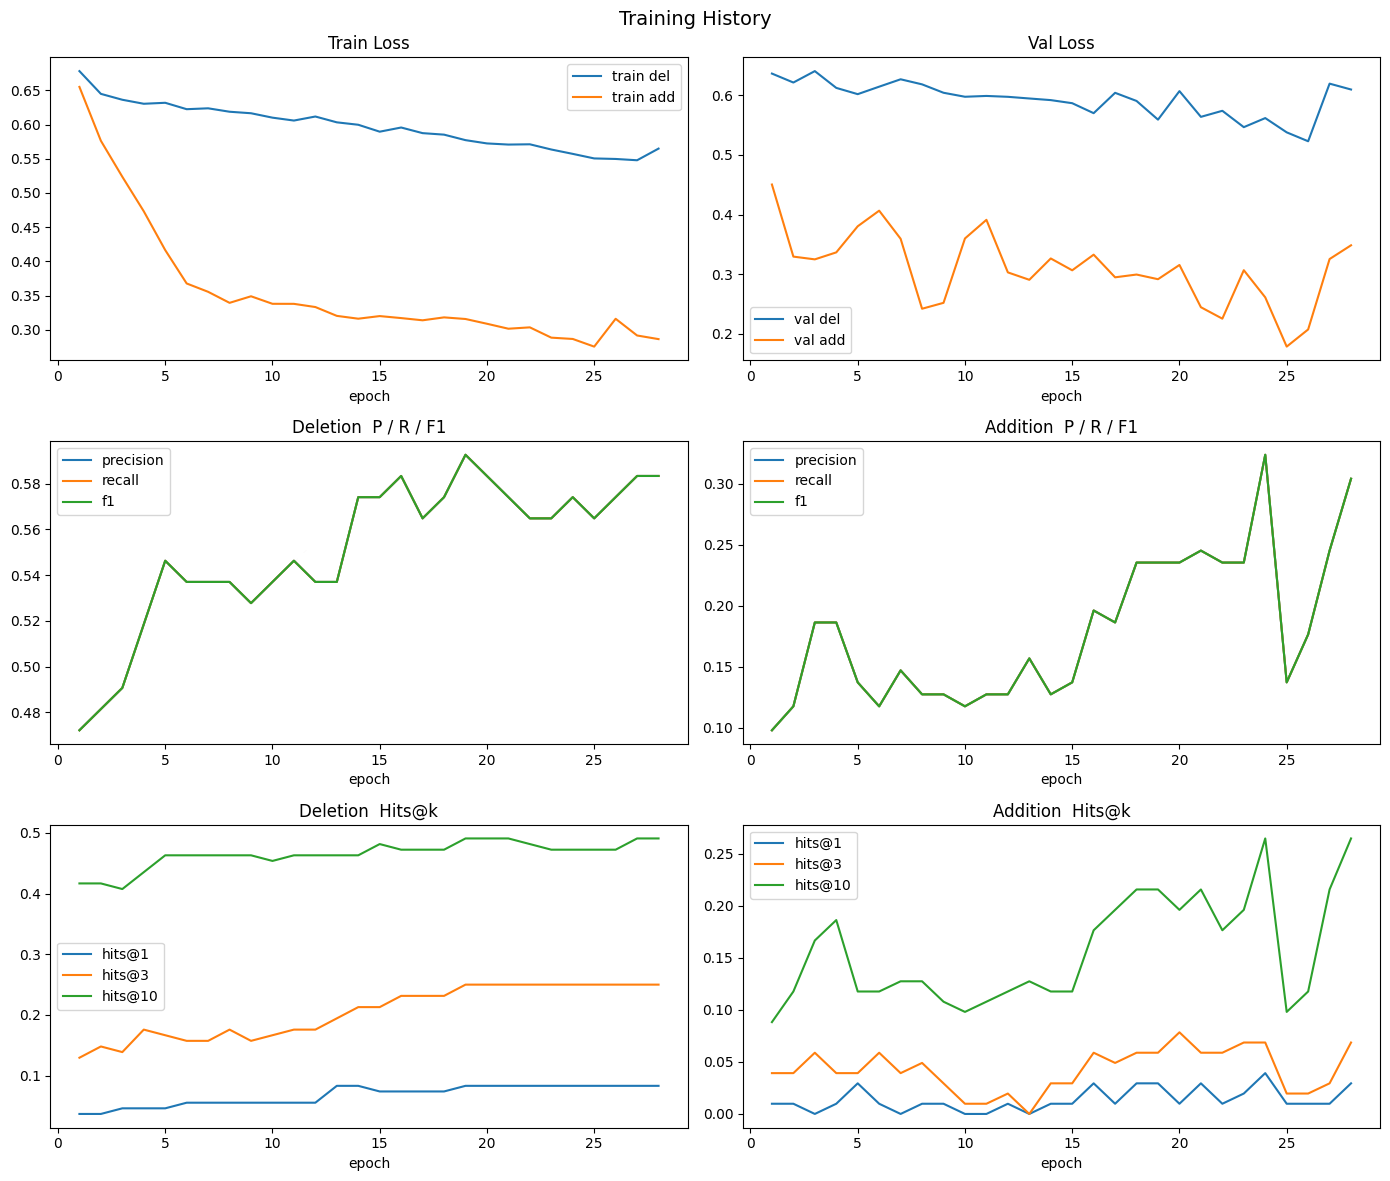

In [ ]:
import matplotlib.pyplot as plt

OUTPUT_DIR = "plots"   # change this to wherever you want
os.makedirs(OUTPUT_DIR, exist_ok=True)

epochs = [h["epoch"] for h in history]

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle("Training History", fontsize=14)

# train loss (del + add)
ax = axes[0, 0]
ax.plot(epochs, [h["train_del_loss"] for h in history], label="train del")
ax.plot(epochs, [h["train_add_loss"] for h in history], label="train add")
ax.set_title("Train Loss")
ax.set_xlabel("epoch")
ax.legend()

# val loss (del + add)
ax = axes[0, 1]
ax.plot(epochs, [h["del_loss"] for h in history], label="val del")
ax.plot(epochs, [h["add_loss"] for h in history], label="val add")
ax.set_title("Val Loss")
ax.set_xlabel("epoch")
ax.legend()

# deletion P / R / F1
ax = axes[1, 0]
ax.plot(epochs, [h["del_precision"] for h in history], label="precision")
ax.plot(epochs, [h["del_recall"]    for h in history], label="recall")
ax.plot(epochs, [h["del_f1"]        for h in history], label="f1")
ax.set_title("Deletion  P / R / F1")
ax.set_xlabel("epoch")
ax.legend()

# addition P / R / F1
ax = axes[1, 1]
ax.plot(epochs, [h["add_precision"] for h in history], label="precision")
ax.plot(epochs, [h["add_recall"]    for h in history], label="recall")
ax.plot(epochs, [h["add_f1"]        for h in history], label="f1")
ax.set_title("Addition  P / R / F1")
ax.set_xlabel("epoch")
ax.legend()

# deletion hits@k
ax = axes[2, 0]
ax.plot(epochs, [h["del_hits@1"]  for h in history], label="hits@1")
ax.plot(epochs, [h["del_hits@3"]  for h in history], label="hits@3")
ax.plot(epochs, [h["del_hits@10"] for h in history], label="hits@10")
ax.set_title("Deletion  Hits@k")
ax.set_xlabel("epoch")
ax.legend()

# addition hits@k
ax = axes[2, 1]
ax.plot(epochs, [h["add_hits@1"]  for h in history], label="hits@1")
ax.plot(epochs, [h["add_hits@3"]  for h in history], label="hits@3")
ax.plot(epochs, [h["add_hits@10"] for h in history], label="hits@10")
ax.set_title("Addition  Hits@k")
ax.set_xlabel("epoch")
ax.legend()

plt.tight_layout()

# ===== save =====
save_path = os.path.join(OUTPUT_DIR, "100bptt_250e_delta_v3.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
# old_model = torch.load(r"models\wikidata12k_bptt100_150e_deltas_v3.pt", weights_only=False)

# model = Temporal_Delta_GNN(
#     in_dim=IN_DIM,
#     hidden_dim=HIDDEN_DIM,
#     edge_emb_dim=EDGE_EMB_DIM,
#     num_edge_types=NUM_EDGE_TYPES,
#     num_gnn_layers=NUM_GNN_LAYERS,
#     heads=HEADS,
#     dropout=DROPOUT,
# ).to(device)


# # # load weight into model
# model.load_state_dict(old_model.state_dict())

<All keys matched successfully>

subgraph: 10 nodes, 12 edges


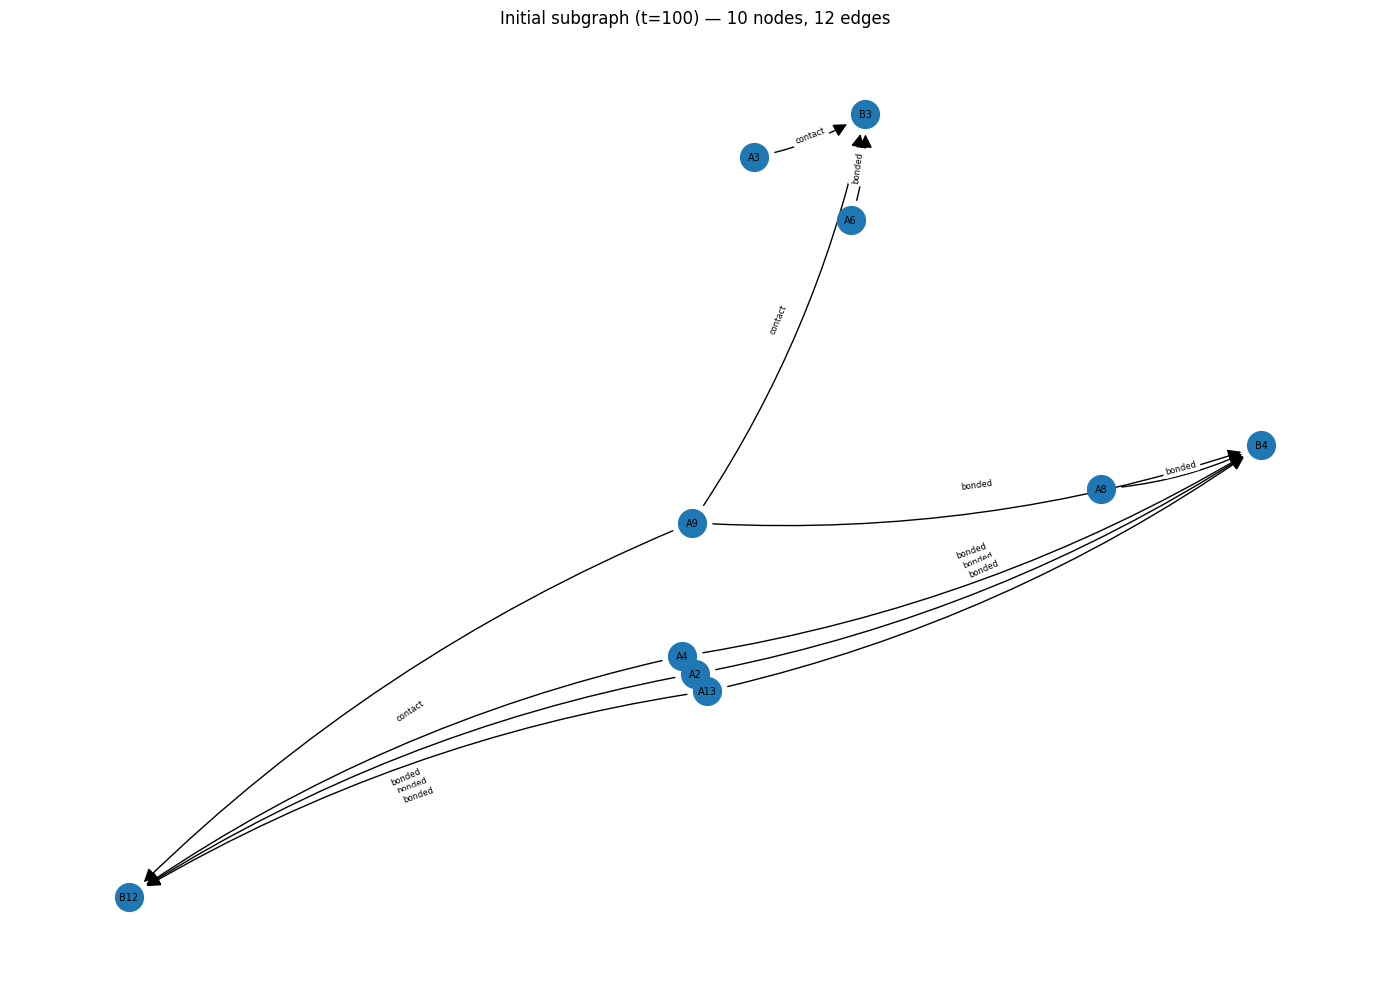

step 1: 10 nodes, 12 edges  +0 added, -0 removed
step 2: 10 nodes, 12 edges  +0 added, -0 removed
step 3: 10 nodes, 12 edges  +0 added, -0 removed
step 4: 10 nodes, 12 edges  +0 added, -0 removed
step 5: 10 nodes, 12 edges  +0 added, -0 removed


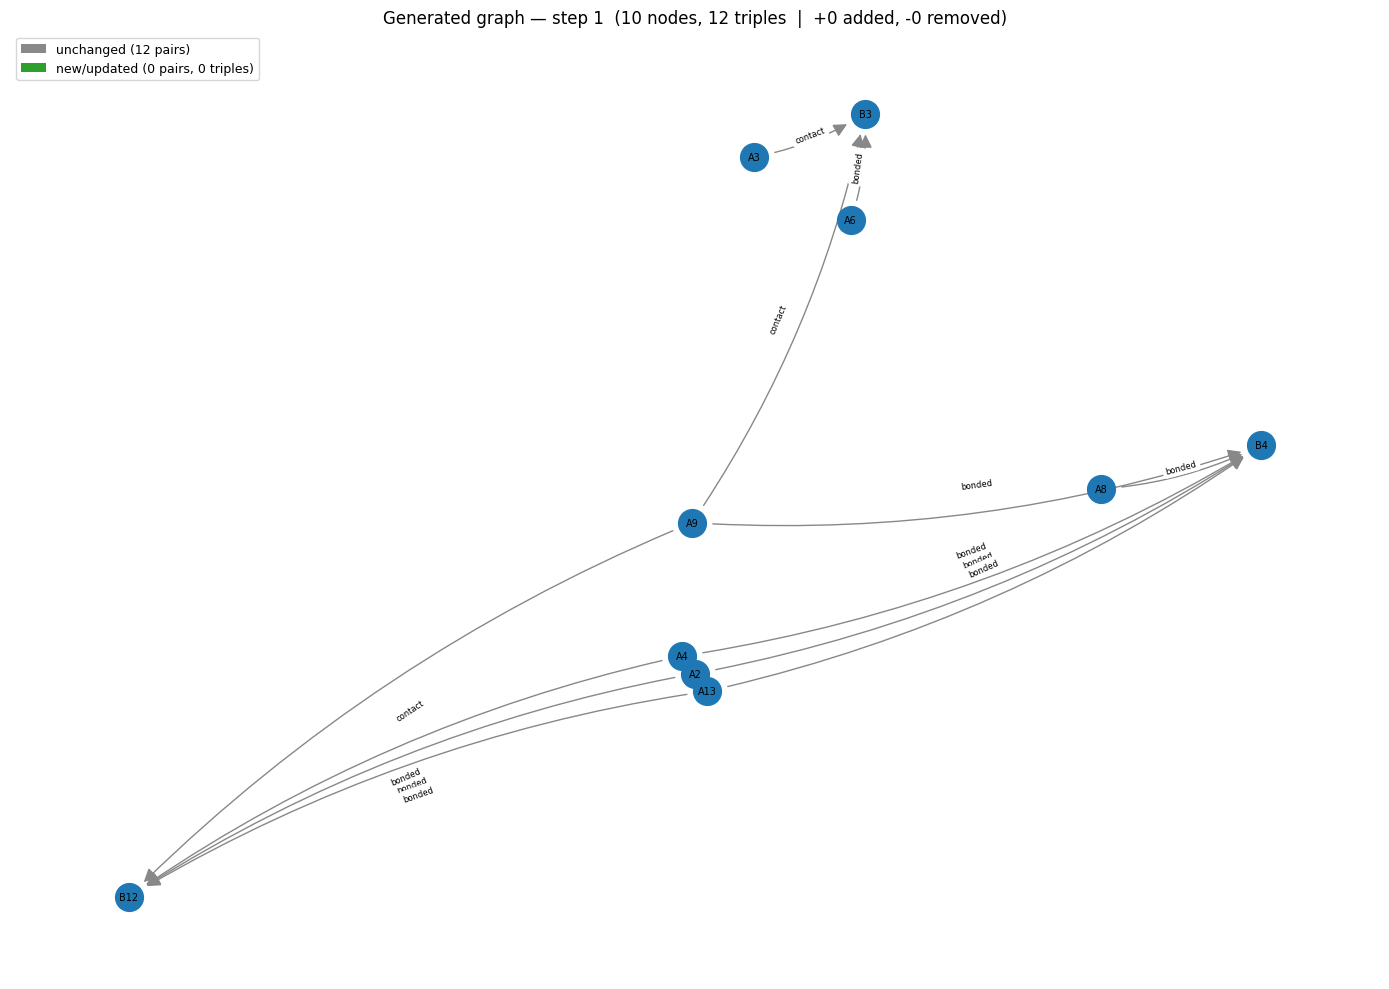

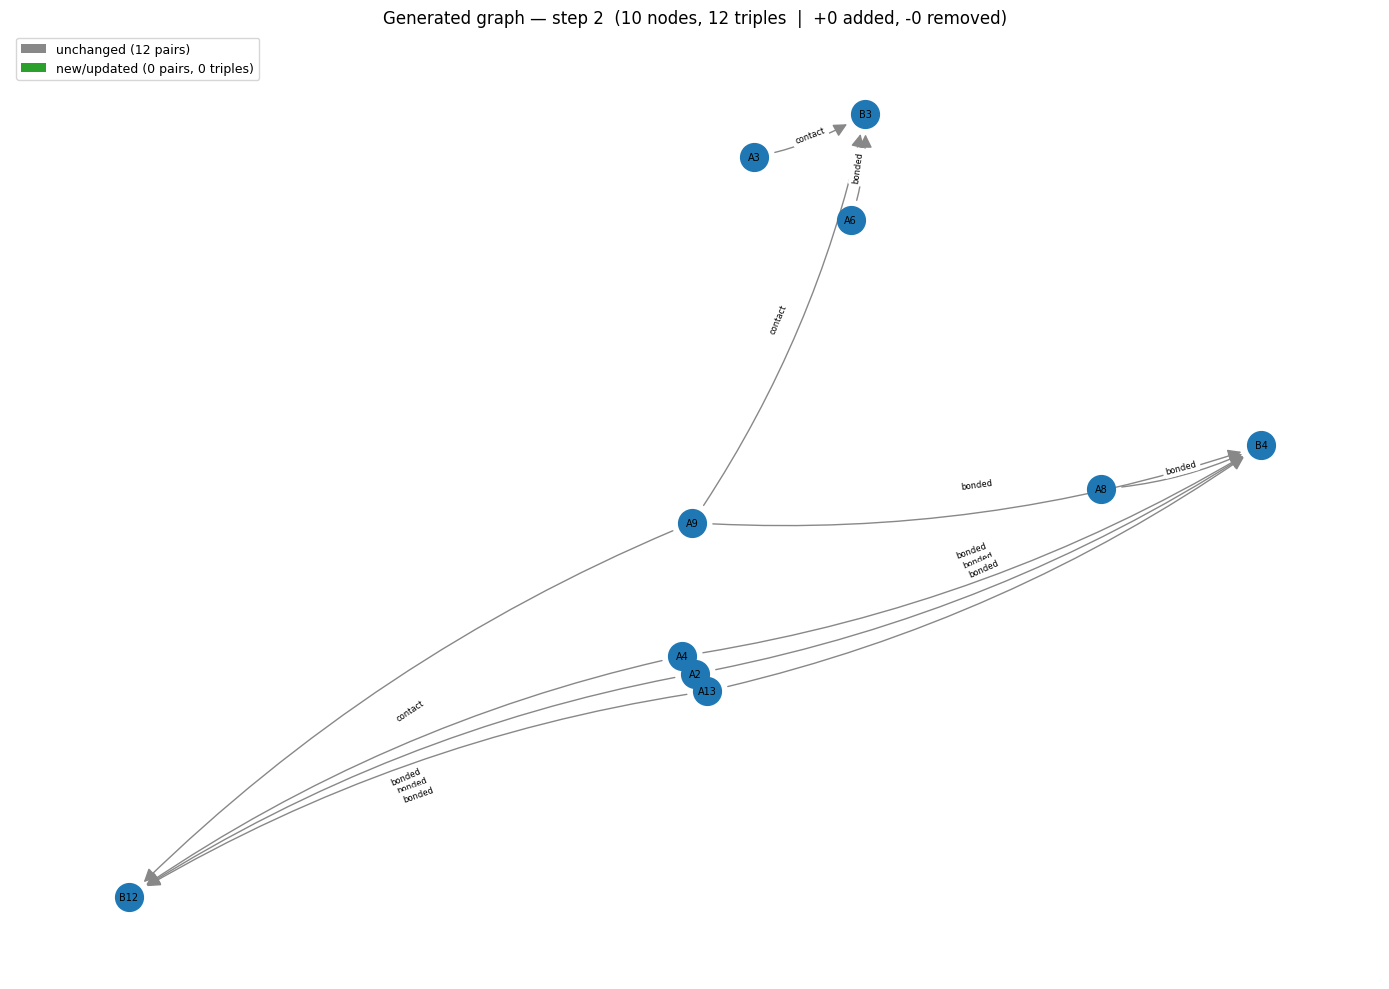

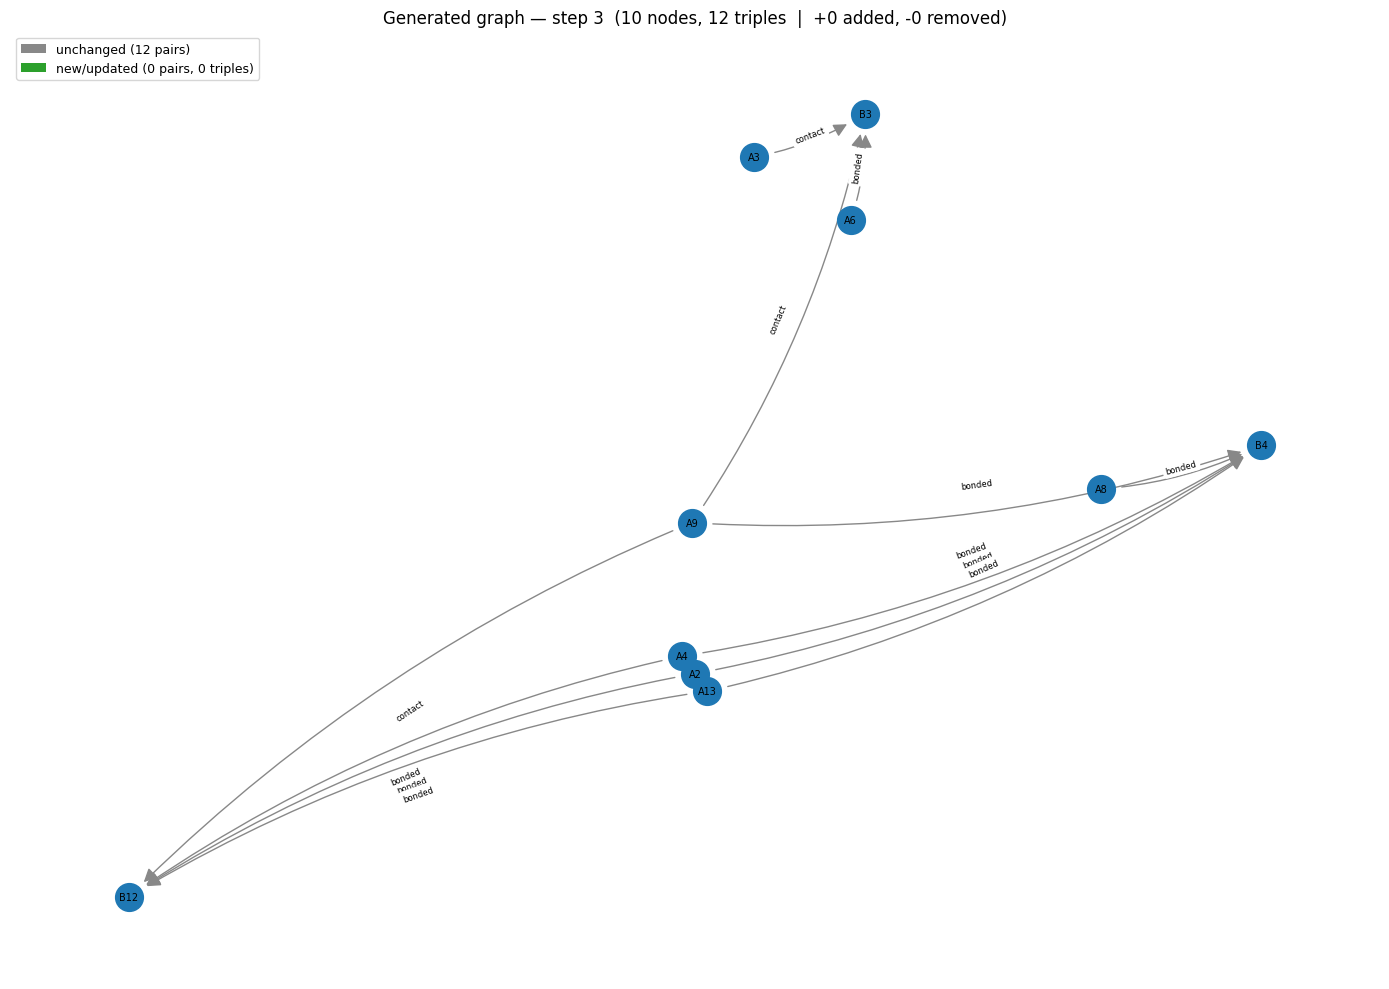

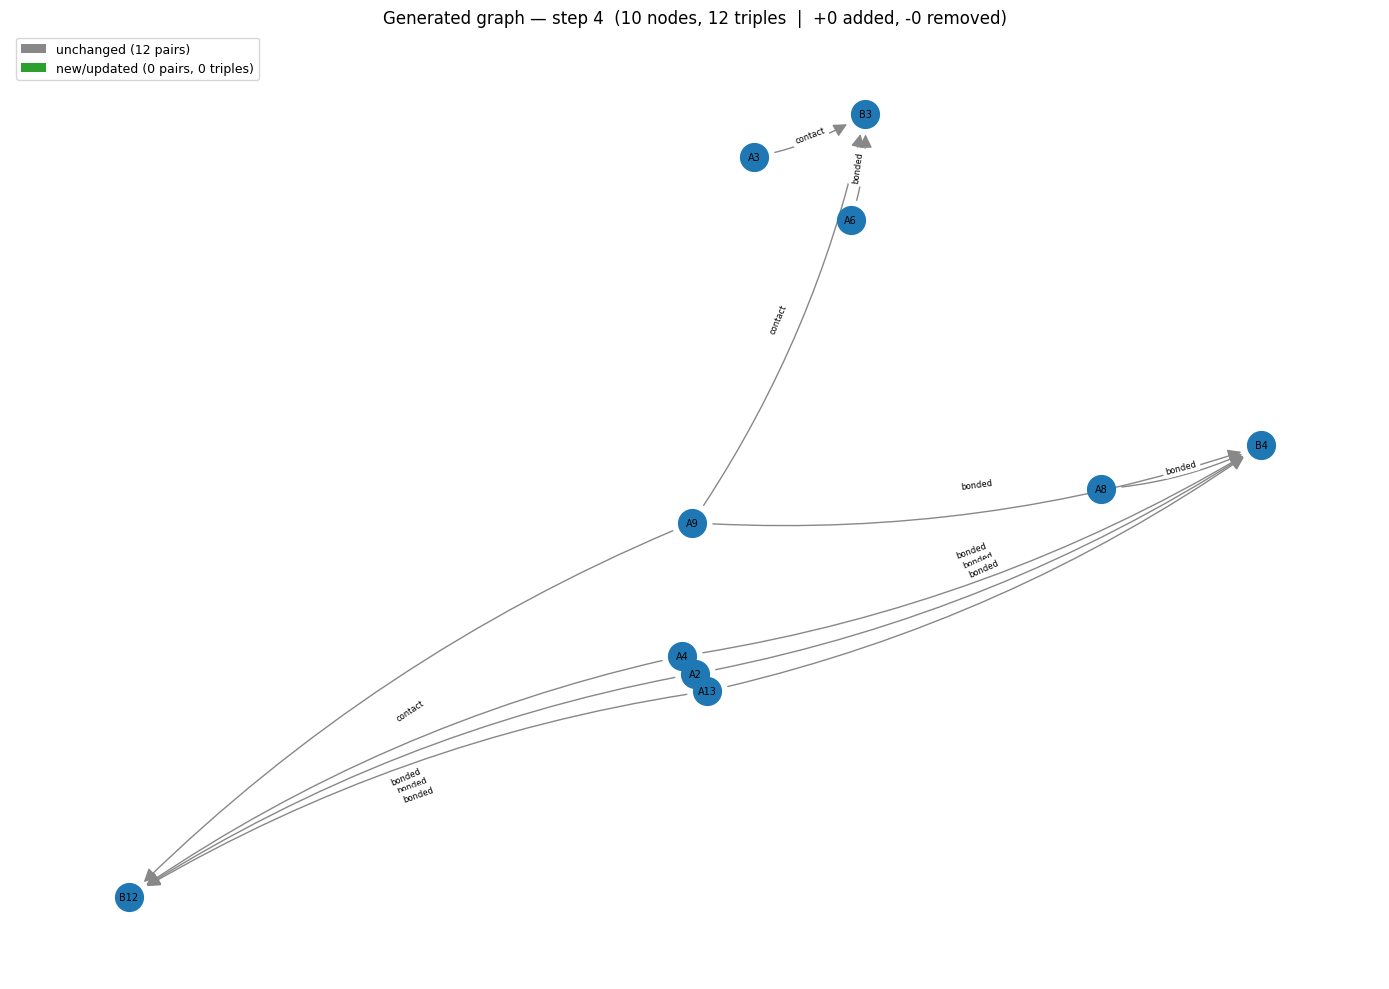

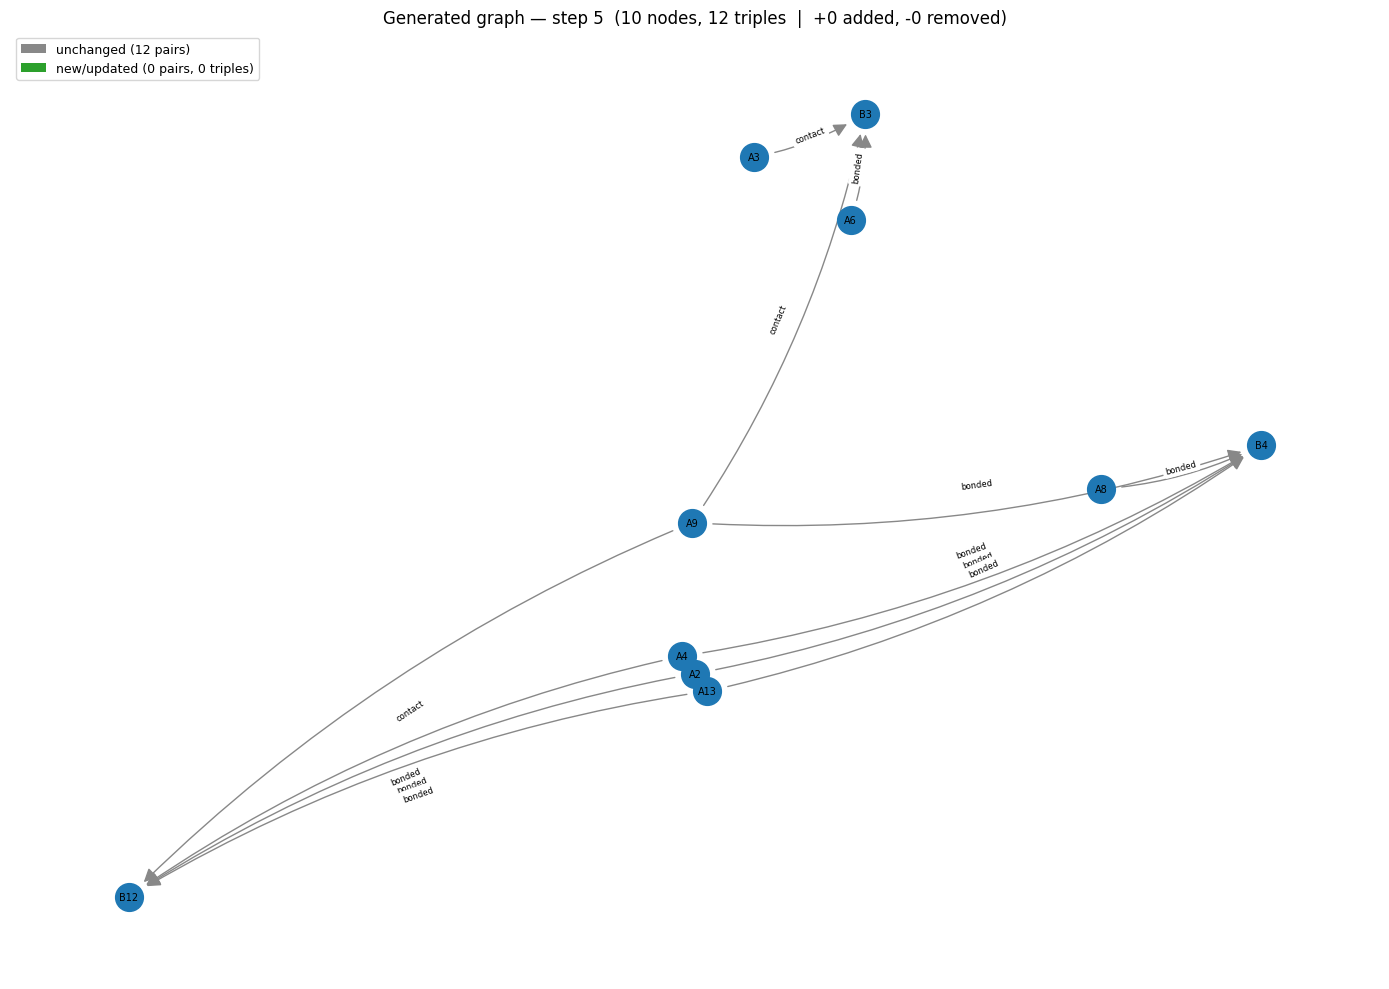

In [30]:
from collections import deque

def sample_subgraph(edge_index, edge_type, num_nodes, seed=None):
    """BFS expansion from a random high-degree node, guaranteeing a connected subgraph."""
    if edge_index.size(1) == 0:
        return edge_index, edge_type

    src_list = edge_index[0].tolist()
    dst_list = edge_index[1].tolist()

    all_nodes, counts = edge_index.flatten().unique(return_counts=True)
    if all_nodes.numel() <= num_nodes:
        return edge_index, edge_type

    # build undirected adjacency for BFS
    neighbors = {}
    for node in all_nodes.tolist():
        neighbors[node] = []
    for s, d in zip(src_list, dst_list):
        neighbors[s].append(d)
        neighbors[d].append(s)

    # pick a random node from the top-k highest-degree nodes for variety
    rng = random.Random(seed)
    topk = min(20, all_nodes.numel())
    _, top_indices = counts.topk(topk)
    seed_node = all_nodes[top_indices[rng.randint(0, topk - 1)]].item()

    visited = {seed_node}
    queue = deque([seed_node])

    while queue and len(visited) < num_nodes:
        node = queue.popleft()
        for nb in neighbors[node]:
            if nb not in visited:
                visited.add(nb)
                queue.append(nb)
                if len(visited) >= num_nodes:
                    break

    mask = torch.tensor(
        [(s in visited and d in visited) for s, d in zip(src_list, dst_list)],
        dtype=torch.bool,
    )
    return edge_index[:, mask], edge_type[mask]


def visualize_step(step_result, prev_edge_set, id_to_entity, id_to_rel, step_num,
                   pos=None, save_path=None):
    """
    Visualize a single gen step. prev_edge_set is the edge set before this step.

    Uses nx.DiGraph which collapses multi-relation edges to one per (src, dst) pair.
    An edge is colored green if ANY triple for that (src, dst) pair is new this step
    (i.e. it appears in step_result["added"]), even if the pair previously existed
    with a different relation.

    pos: optional fixed node-position dict. Pass the same dict to every call so
         nodes stay in place across steps — makes it easy to see which edges
         appeared or disappeared between steps. If None, a new layout is computed.
    """
    from matplotlib.patches import Patch

    new_triples = sorted(step_result["edge_set"])
    num_triples = len(new_triples)

    # (src_id, dst_id) pairs that gained at least one new relation this step.
    # using the added set directly is more correct than comparing prev entity pairs:
    # it catches new relations on existing pairs (DiGraph collapses them, but they
    # still represent a real graph change).
    changed_pairs = {(s, d) for s, r, d in step_result["added"]}

    G = nx.DiGraph()
    for src_id, rel_id, dst_id in new_triples:
        src_lbl = id_to_entity.get(src_id, str(src_id))
        dst_lbl = id_to_entity.get(dst_id, str(dst_id))
        rel_lbl = id_to_rel.get(rel_id, str(rel_id))
        is_new  = (src_id, dst_id) in changed_pairs
        G.add_edge(src_lbl, dst_lbl, relation=rel_lbl, is_new=is_new)

    # use the provided fixed layout, or compute a new one for this graph.
    # a fixed layout (computed from the initial graph and reused) keeps nodes in
    # place across steps so you can visually track edge changes.
    if pos is None:
        step_pos = nx.spring_layout(G, seed=42)
    else:
        # place any new nodes (not in initial layout) at the centroid
        import numpy as np
        centroid = np.mean(list(pos.values()), axis=0) if pos else [0.0, 0.0]
        step_pos = {n: pos.get(n, centroid) for n in G.nodes()}

    fig, ax = plt.subplots(figsize=(14, 10))
    nx.draw_networkx_nodes(G, step_pos, node_size=400, ax=ax)
    nx.draw_networkx_labels(G, step_pos, font_size=7, ax=ax)

    kept_edges    = [(u, v) for u, v, d in G.edges(data=True) if not d['is_new']]
    changed_edges = [(u, v) for u, v, d in G.edges(data=True) if d['is_new']]

    nx.draw_networkx_edges(
        G, step_pos, edgelist=kept_edges, ax=ax,
        arrows=True, arrowstyle='-|>', arrowsize=20,
        edge_color='#888888', connectionstyle='arc3,rad=0.1',
        min_source_margin=15, min_target_margin=15,
    )
    nx.draw_networkx_edges(
        G, step_pos, edgelist=changed_edges, ax=ax,
        arrows=True, arrowstyle='-|>', arrowsize=20,
        edge_color='#2ca02c', connectionstyle='arc3,rad=0.1',
        min_source_margin=15, min_target_margin=15,
    )
    nx.draw_networkx_edge_labels(
        G, step_pos, edge_labels=nx.get_edge_attributes(G, 'relation'),
        font_size=6, ax=ax,
    )

    legend_elements = [
        Patch(facecolor='#888888', label=f'unchanged ({len(kept_edges)} pairs)'),
        Patch(facecolor='#2ca02c', label=f'new/updated ({len(changed_edges)} pairs, {len(step_result["added"])} triples)'),
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax.set_title(
        f"Generated graph — step {step_num}  "
        f"({G.number_of_nodes()} nodes, {num_triples} triples  |  "
        f"+{len(step_result['added'])} added, -{len(step_result['removed'])} removed)"
    )
    ax.axis('off')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=100)
        plt.close(fig)
    else:
        ipy_display(fig)
        plt.close(fig)

    # print added / removed edges
    for src_id, rel_id, dst_id in sorted(step_result['added']):
        src_lbl = id_to_entity.get(src_id, str(src_id))
        dst_lbl = id_to_entity.get(dst_id, str(dst_id))
        rel_lbl = id_to_rel.get(rel_id, str(rel_id))
        print(f"  + {src_lbl} --[{rel_lbl}]--> {dst_lbl}")
    for src_id, rel_id, dst_id in sorted(step_result['removed']):
        src_lbl = id_to_entity.get(src_id, str(src_id))
        dst_lbl = id_to_entity.get(dst_id, str(dst_id))
        rel_lbl = id_to_rel.get(rel_id, str(rel_id))
        print(f"  - {src_lbl} --[{rel_lbl}]--> {dst_lbl}")


# ---- run ----
SUBGRAPH_NODES = 10
SUBGRAPH_SEED  = 500   # set to an int for a reproducible subgraph, None for random
T_START        = 100   # which dataset timestep to start from

start = dataset[T_START]
sub_edge_index, sub_edge_type = sample_subgraph(
    start.edge_index, start.edge_type, num_nodes=SUBGRAPH_NODES, seed=SUBGRAPH_SEED
)
print(f"subgraph: {sub_edge_index.unique().numel()} nodes, {sub_edge_index.size(1)} edges")

# build and display initial graph, computing the fixed layout here so all
# subsequent steps share the same node positions
G_init = nx.DiGraph()
for src_id, rel_id, dst_id in zip(sub_edge_index[0].tolist(), sub_edge_type.tolist(), sub_edge_index[1].tolist()):
    G_init.add_edge(
        dataset.id_to_entity.get(src_id, str(src_id)),
        dataset.id_to_entity.get(dst_id, str(dst_id)),
        relation=dataset.id_to_rel.get(rel_id, str(rel_id)),
    )

# fixed layout — computed once from the initial graph and reused for all steps
fixed_pos = nx.spring_layout(G_init, seed=42)

fig, ax = plt.subplots(figsize=(14, 10))
nx.draw_networkx_nodes(G_init, fixed_pos, node_size=400, ax=ax)
nx.draw_networkx_labels(G_init, fixed_pos, font_size=7, ax=ax)
nx.draw_networkx_edges(
    G_init, fixed_pos, ax=ax, arrows=True, arrowstyle='-|>', arrowsize=20,
    connectionstyle='arc3,rad=0.1', min_source_margin=15, min_target_margin=15,
)
nx.draw_networkx_edge_labels(
    G_init, fixed_pos, edge_labels=nx.get_edge_attributes(G_init, 'relation'), font_size=6, ax=ax,
)
ax.set_title(f"Initial subgraph (t={T_START}) — {G_init.number_of_nodes()} nodes, {G_init.number_of_edges()} edges")
ax.axis('off')
plt.tight_layout()
plt.show()

# run gen — returns list of step dicts
# sampling='bernoulli' for stochastic sampling, 'threshold' to use add/del_threshold
steps = model.gen(
    x_global      = dataset.x_global,
    edge_index    = sub_edge_index,
    edge_type     = sub_edge_type,
    num_steps     = 5,
    device        = device,
    sampling      = "threshold", #'bernoulli',
    add_threshold = 0.9,
    del_threshold = 0.9,
)

# visualize each step with the shared fixed layout so node positions are stable
init_edge_set = set(zip(
    sub_edge_index[0].tolist(),
    sub_edge_type.tolist(),
    sub_edge_index[1].tolist(),
))
prev = init_edge_set
for i, step in enumerate(steps):
    visualize_step(step, prev, dataset.id_to_entity, dataset.id_to_rel,
                   step_num=i + 1, pos=fixed_pos)
    prev = step["edge_set"]

In [ ]:
# import os
# from datetime import datetime

# save_dir = "models"
# os.makedirs(save_dir, exist_ok=True)

# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
# save_path = os.path.join(save_dir, f"temporal_gnn_{timestamp}.pt")

# torch.save(model, save_path)
# print(f"saved full model to {save_path}")